In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/Crop_recommendation.csv
/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/price_dataset.csv


In [102]:
# Core Libraries
import os
import random
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#pipeline
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import top_k_accuracy_score

# XGBoost
from xgboost import XGBClassifier

# Explainable AI
import shap

# Model Saving
import joblib

In [72]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Random State:", RANDOM_STATE)

warnings.filterwarnings("ignore")

Random State: 42


In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [6]:
OUTPUT_DIR = "/kaggle/working/crop_recommendation"

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR = os.path.join(OUTPUT_DIR, "results")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

for directory in [
    OUTPUT_DIR,
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Output Directory:", OUTPUT_DIR)
print("Model Directory:", MODEL_DIR)
print("Results Directory:", RESULT_DIR)
print("Figure Directory:", FIGURE_DIR)

Output Directory: /kaggle/working/crop_recommendation
Model Directory: /kaggle/working/crop_recommendation/models
Results Directory: /kaggle/working/crop_recommendation/results
Figure Directory: /kaggle/working/crop_recommendation/figures


In [7]:
CROP_DATA_PATH = "/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/Crop_recommendation.csv"

print("Dataset Path:", CROP_DATA_PATH)

Dataset Path: /kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/Crop_recommendation.csv


In [8]:
crop_df = pd.read_csv(CROP_DATA_PATH)

print("Crop dataset loaded successfully.")
print(f"Rows    : {crop_df.shape[0]}")
print(f"Columns : {crop_df.shape[1]}")

display(crop_df.head())

Crop dataset loaded successfully.
Rows    : 18079
Columns : 8


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Unnamed: 0,Crop,N,P,K,pH,rainfall,temperature
0,10182,barley,70,40,45,5.5400,75.3200,22.6760
1,16280,sunflower,50,60,30,5.5400,297.6600,29.5667
2,54944,sweetpotato,90,20,120,5.0200,689.8800,29.0373
3,98212,rice,80,40,40,5.6600,297.6600,29.5667
4,52108,soyabean,20,60,20,5.3800,1011.4900,30.4300


In [118]:
FEATURES = [
    "N",
    "P",
    "K",
    "pH",
    "rainfall",
    "temperature"
]

TARGET = "Crop"

print("Features:", FEATURES)
print("Target:", TARGET)

joblib.dump(
    FEATURES,
    os.path.join(
        MODEL_DIR,
        "crop_features.pkl"
    )
)

Features: ['N', 'P', 'K', 'pH', 'rainfall', 'temperature']
Target: Crop


['/kaggle/working/crop_recommendation/models/crop_features.pkl']

In [10]:
required_columns = FEATURES + [TARGET]

missing_columns = [
    col for col in required_columns
    if col not in crop_df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing from crop dataset: {missing_columns}"
    )

print("Crop dataset schema validation passed.")

Crop dataset schema validation passed.


In [11]:
print("\nDataset Information:")
crop_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18079 entries, 0 to 18078
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   18079 non-null  int64  
 1   Crop         18079 non-null  object 
 2   N            18079 non-null  int64  
 3   P            18079 non-null  int64  
 4   K            18079 non-null  int64  
 5   pH           18079 non-null  float64
 6   rainfall     18079 non-null  float64
 7   temperature  18079 non-null  float64
dtypes: float64(3), int64(4), object(1)
memory usage: 1.1+ MB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
print("\nShape:")
print(crop_df.shape)

print("\nColumn Names:")
print(crop_df.columns.tolist())

print("\nFirst 5 Rows:")
display(crop_df.head())


Shape:
(18079, 8)

Column Names:
['Unnamed: 0', 'Crop', 'N', 'P', 'K', 'pH', 'rainfall', 'temperature']

First 5 Rows:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Unnamed: 0,Crop,N,P,K,pH,rainfall,temperature
0,10182,barley,70,40,45,5.5400,75.3200,22.6760
1,16280,sunflower,50,60,30,5.5400,297.6600,29.5667
2,54944,sweetpotato,90,20,120,5.0200,689.8800,29.0373
3,98212,rice,80,40,40,5.6600,297.6600,29.5667
4,52108,soyabean,20,60,20,5.3800,1011.4900,30.4300


In [13]:
if "Unnamed: 0" in crop_df.columns:
    crop_df = crop_df.drop(columns=["Unnamed: 0"])

print("Current dataset shape:", crop_df.shape)
print(crop_df.columns.tolist())

Current dataset shape: (18079, 7)
['Crop', 'N', 'P', 'K', 'pH', 'rainfall', 'temperature']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
print(f"Number of observations : {crop_df.shape[0]}")
print(f"Number of variables    : {crop_df.shape[1]}")
print(f"Input features         : {len(FEATURES)}")
print(f"Target variable        : {TARGET}")

Number of observations : 18079
Number of variables    : 7
Input features         : 6
Target variable        : Crop


In [15]:
numeric_features = crop_df[FEATURES].select_dtypes(
    include=np.number
).columns.tolist()

non_numeric_features = [
    feature
    for feature in FEATURES
    if feature not in numeric_features
]

print("\nNumeric features:")
print(numeric_features)

if non_numeric_features:
    print("\nWARNING: Expected numeric features found as non-numeric:")
    print(non_numeric_features)
else:
    print("\nAll input features are numeric.")


Numeric features:
['N', 'P', 'K', 'pH', 'rainfall', 'temperature']

All input features are numeric.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
missing_values = crop_df.isnull().sum()

missing_percentage = (
    crop_df.isnull().mean() * 100
)

missing_df = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

display(missing_df)

,Missing_Count,Missing_Percentage
Crop,0,0.0000
N,0,0.0000
P,0,0.0000
K,0,0.0000
pH,0,0.0000
rainfall,0,0.0000
temperature,0,0.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
print("Number of unique crops:", crop_df[TARGET].nunique())

print("\nCrop Labels:")
print(
    sorted(
        crop_df[TARGET]
        .astype(str)
        .unique()
    )
)

Number of unique crops: 40

Crop Labels:
['banana', 'barley', 'bittergourd', 'blackgram', 'blackpepper', 'bottlegourd', 'brinjal', 'cabbage', 'cardamom', 'cauliflower', 'coriander', 'cotton', 'cucumber', 'drumstick', 'garlic', 'grapes', 'horsegram', 'jackfruit', 'jowar', 'jute', 'ladyfinger', 'maize', 'mango', 'moong', 'onion', 'orange', 'papaya', 'pineapple', 'potato', 'pumpkin', 'radish', 'ragi', 'rapeseed', 'rice', 'soyabean', 'sunflower', 'sweetpotato', 'tomato', 'turmeric', 'wheat']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
original_labels = crop_df[TARGET].astype(str)

stripped_labels = original_labels.str.strip()

space_issues = (
    original_labels != stripped_labels
).sum()

print("Labels containing leading/trailing spaces:", space_issues)

Labels containing leading/trailing spaces: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
crop_counts = (
    crop_df[TARGET]
    .value_counts()
    .sort_values(ascending=False)
)

crop_distribution = pd.DataFrame({
    "Crop": crop_counts.index,
    "Sample_Count": crop_counts.values,
    "Percentage": (
        crop_counts.values /
        len(crop_df) * 100
    )
})

display(crop_distribution)

,Crop,Sample_Count,Percentage
0,rice,2245,12.4177
1,maize,1976,10.9298
2,moong,1327,7.3400
3,wheat,1287,7.1188
4,rapeseed,1118,6.1840
5,potato,1083,5.9904
6,jowar,1055,5.8355
7,onion,1047,5.7912
8,sunflower,737,4.0766
9,barley,654,3.6175


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
print("Number of crop classes :", len(crop_counts))
print("Largest class size     :", crop_counts.max())
print("Smallest class size    :", crop_counts.min())

imbalance_ratio = (
    crop_counts.max() /
    crop_counts.min()
)

print(
    f"Max/Min Imbalance Ratio: {imbalance_ratio:.2f}"
)

Number of crop classes : 40
Largest class size     : 2245
Smallest class size    : 9
Max/Min Imbalance Ratio: 249.44


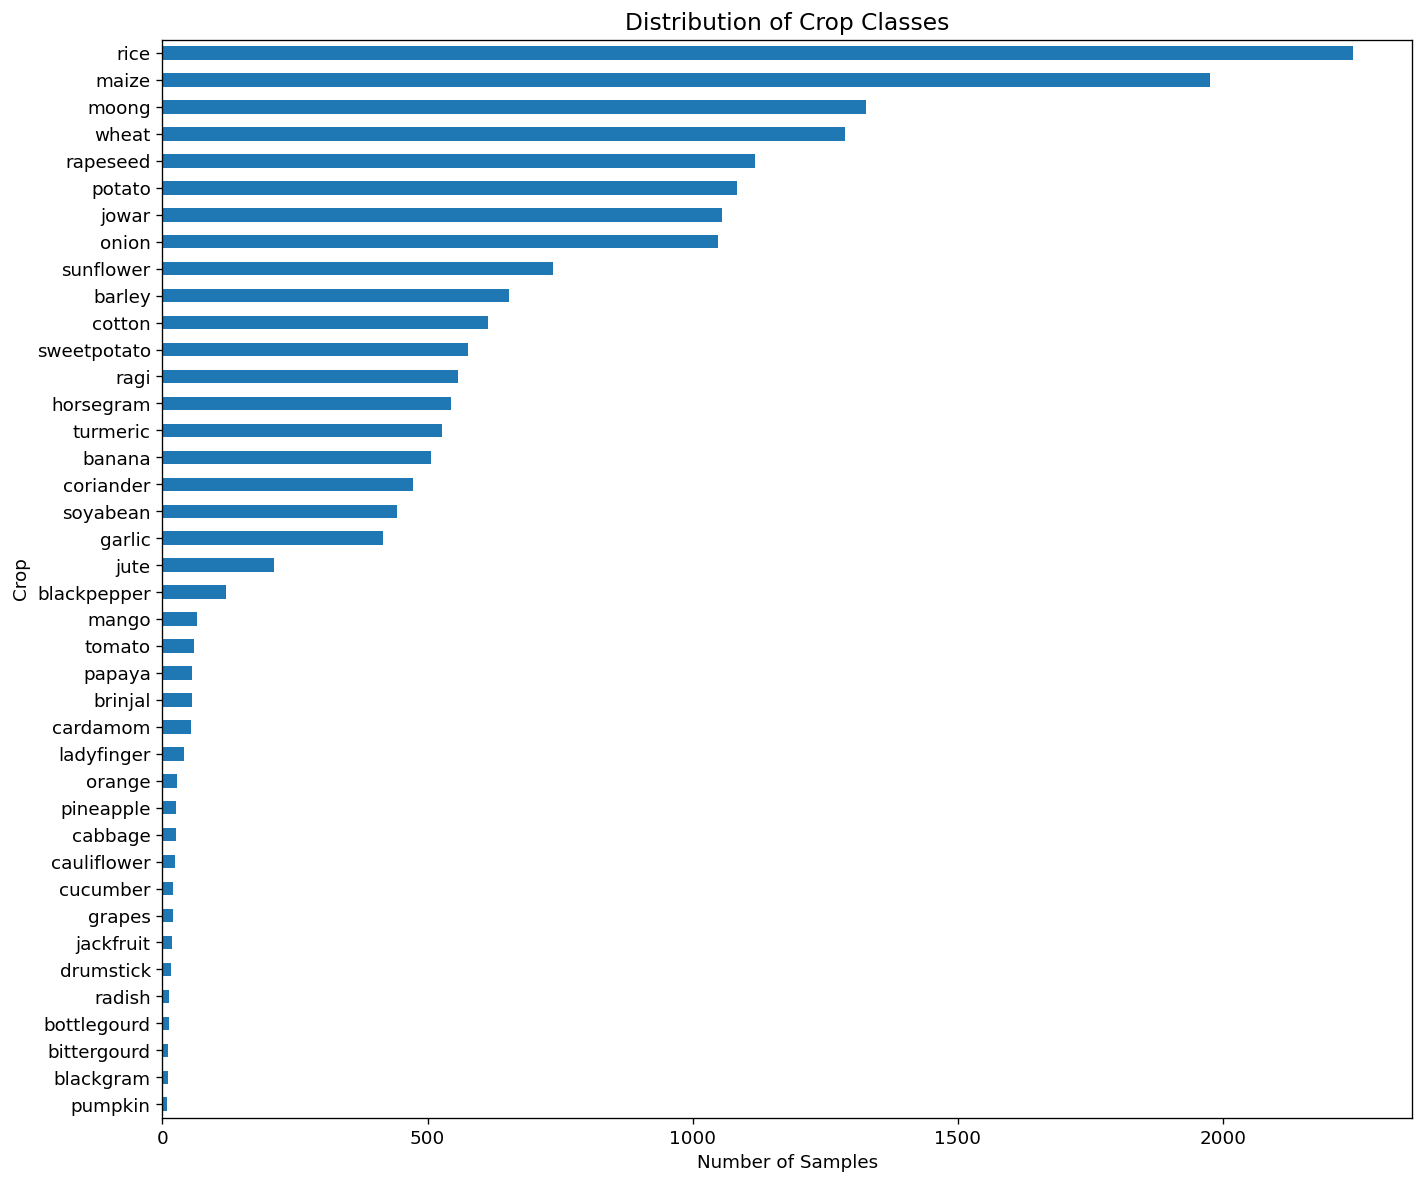

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
plt.figure(figsize=(12, 10))

crop_counts.sort_values().plot(
    kind="barh"
)

plt.title(
    "Distribution of Crop Classes",
    fontsize=14
)

plt.xlabel("Number of Samples")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "crop_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
threshold = 50

rare_crops = crop_counts[
    crop_counts < threshold
]

print(
    f"Crops with fewer than {threshold} samples:"
)

display(
    rare_crops.to_frame(
        name="Sample_Count"
    )
)

Crops with fewer than 50 samples:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Sample_Count
Crop,
ladyfinger,41
orange,27
cabbage,26
pineapple,26
cauliflower,23
cucumber,20
grapes,19
jackfruit,18
drumstick,17


In [23]:
summary["median"] = crop_df[FEATURES].median()
summary["skewness"] = crop_df[FEATURES].skew()
summary["missing"] = crop_df[FEATURES].isnull().sum()
display(summary)

NameError: name 'summary' is not defined

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for feature in ["N", "P", "K"]:
    
    negative_count = (
        crop_df[feature] < 0
    ).sum()

    print(
        f"{feature} negative values:",
        negative_count
    )

print(
    "Negative rainfall:",
    (crop_df["rainfall"] < 0).sum()
)

print(
    "Temperature range:",
    crop_df["temperature"].min(),
    "to",
    crop_df["temperature"].max()
)

invalid_ph = crop_df[
    (crop_df["pH"] < 0) |
    (crop_df["pH"] > 14)
]

print(
    "pH values outside 0–14:",
    len(invalid_ph)
)

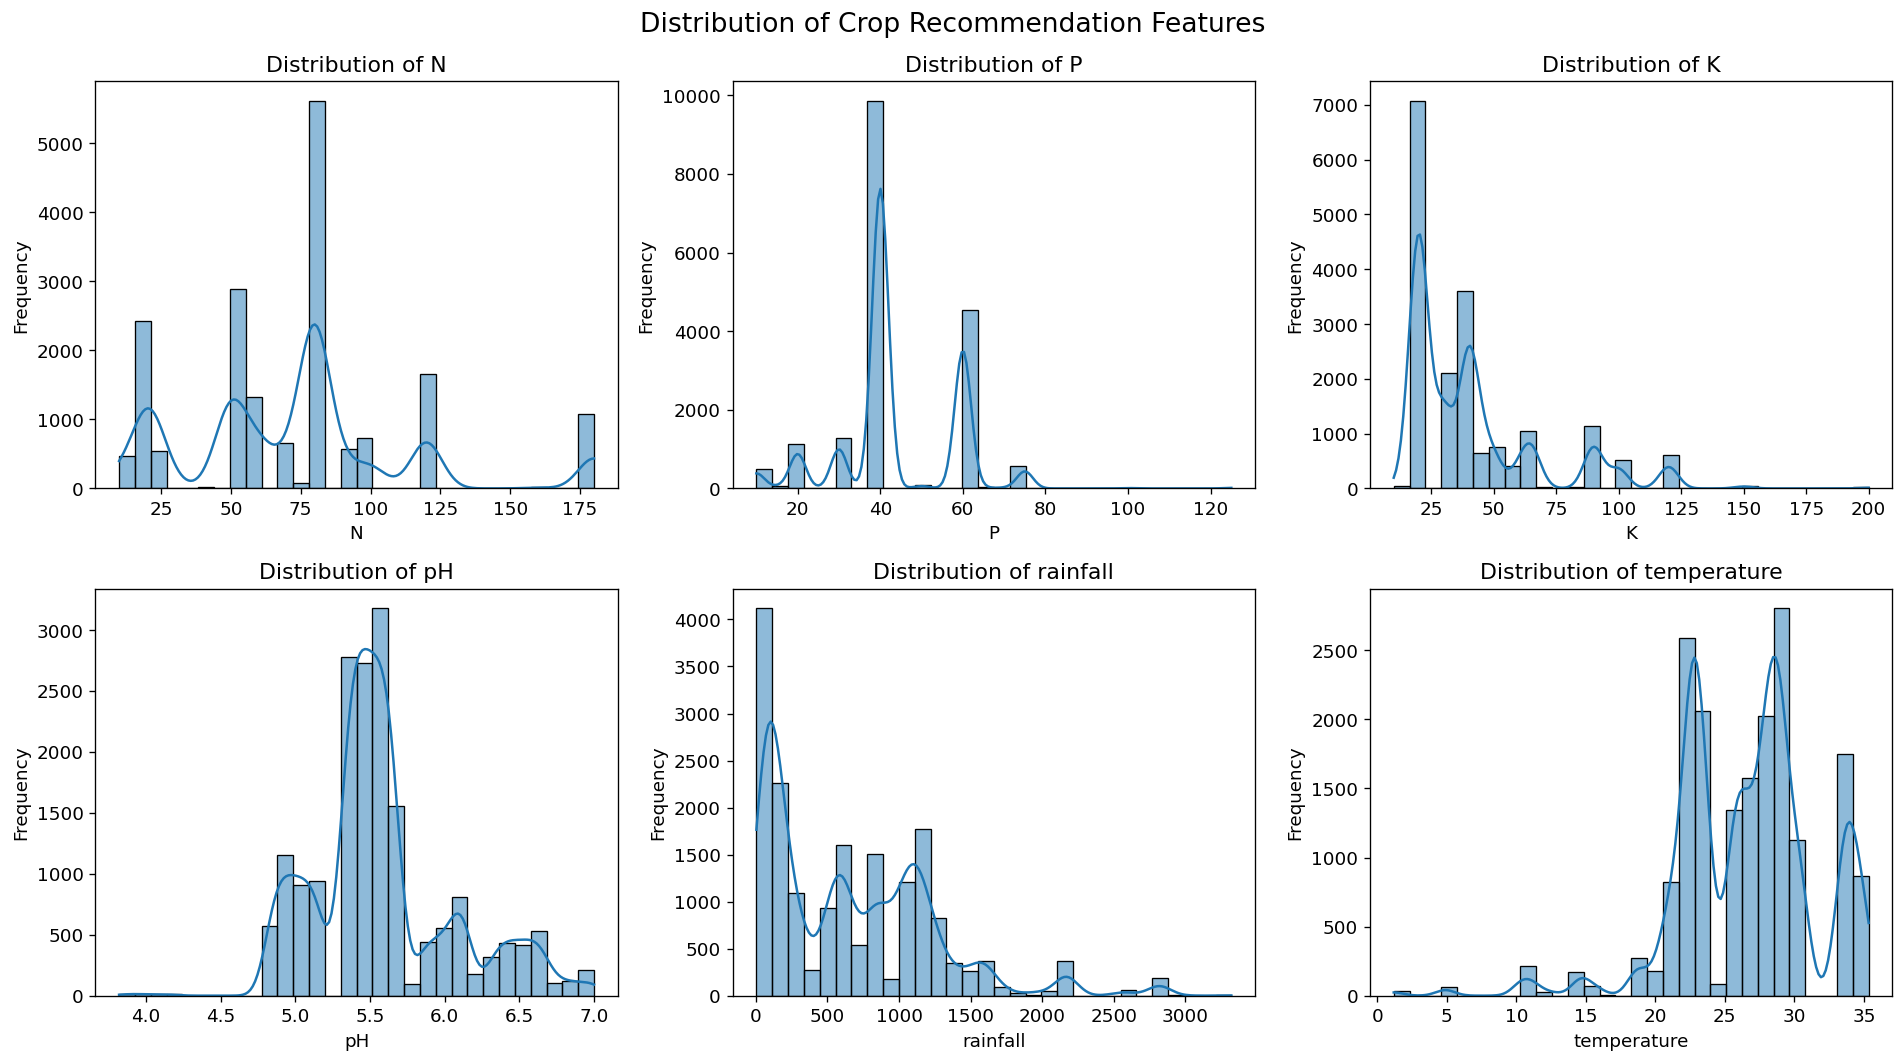

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, feature in enumerate(FEATURES):

    sns.histplot(
        crop_df[feature],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {feature}"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Crop Recommendation Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "feature_distributions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
skewness_df = pd.DataFrame({
    "Feature": FEATURES,
    "Skewness": [
        crop_df[feature].skew()
        for feature in FEATURES
    ]
})

skewness_df["Absolute_Skewness"] = (
    skewness_df["Skewness"].abs()
)

skewness_df = skewness_df.sort_values(
    "Absolute_Skewness",
    ascending=False
)

display(skewness_df)

,Feature,Skewness,Absolute_Skewness
2,K,1.6116,1.6116
4,rainfall,1.0877,1.0877
0,N,0.8497,0.8497
5,temperature,-0.7944,0.7944
3,pH,0.7354,0.7354
1,P,0.2636,0.2636


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to repr

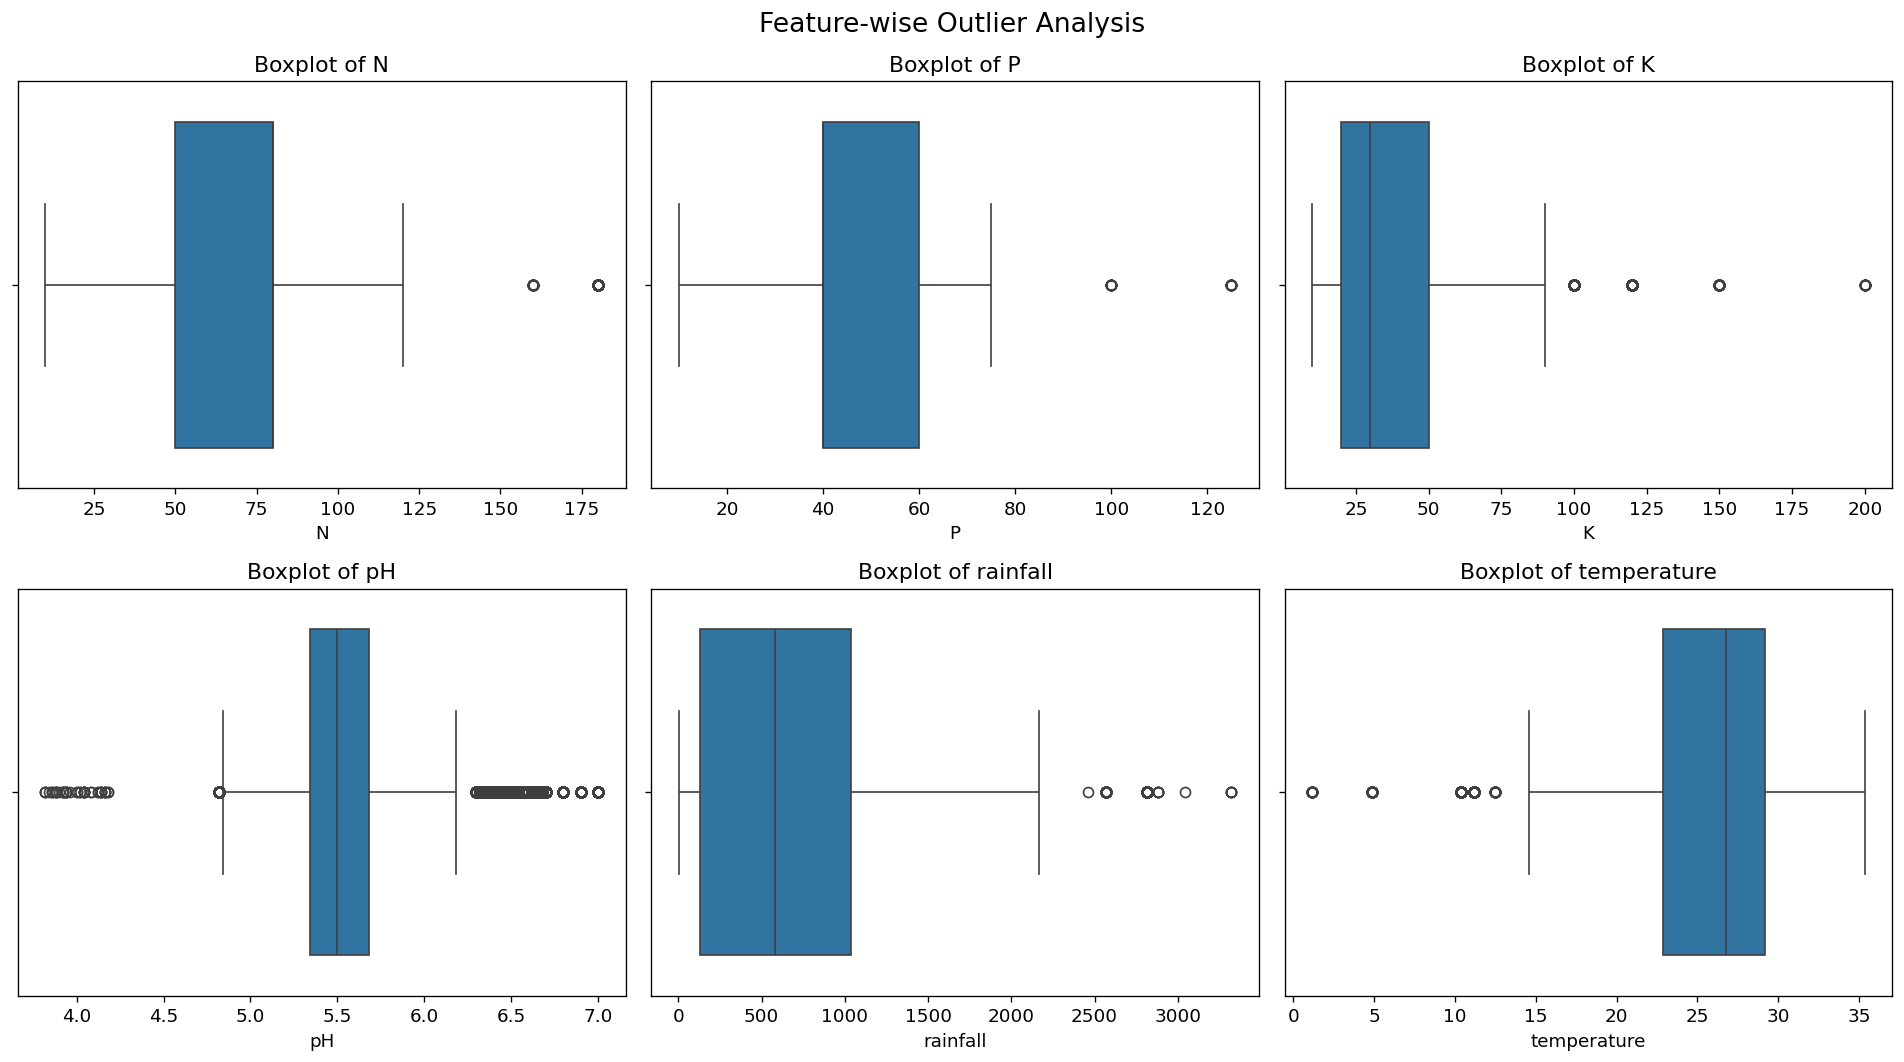

In [26]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, feature in enumerate(FEATURES):

    sns.boxplot(
        x=crop_df[feature],
        ax=axes[i]
    )

    axes[i].set_title(
        f"Boxplot of {feature}"
    )

plt.suptitle(
    "Feature-wise Outlier Analysis",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "feature_boxplots.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
outlier_summary = []

for feature in FEATURES:

    Q1 = crop_df[feature].quantile(0.25)
    Q3 = crop_df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = crop_df[
        (crop_df[feature] < lower_bound) |
        (crop_df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage":
            len(outliers) / len(crop_df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,N,5.0000,125.0000,1109,6.1342
1,P,10.0000,90.0000,32,0.1770
2,K,-25.0000,95.0000,1203,6.6541
3,pH,4.8300,6.1900,2361,13.0594
4,rainfall,-1236.7800,2401.7800,256,1.4160
5,temperature,13.4477,38.6295,346,1.9138


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


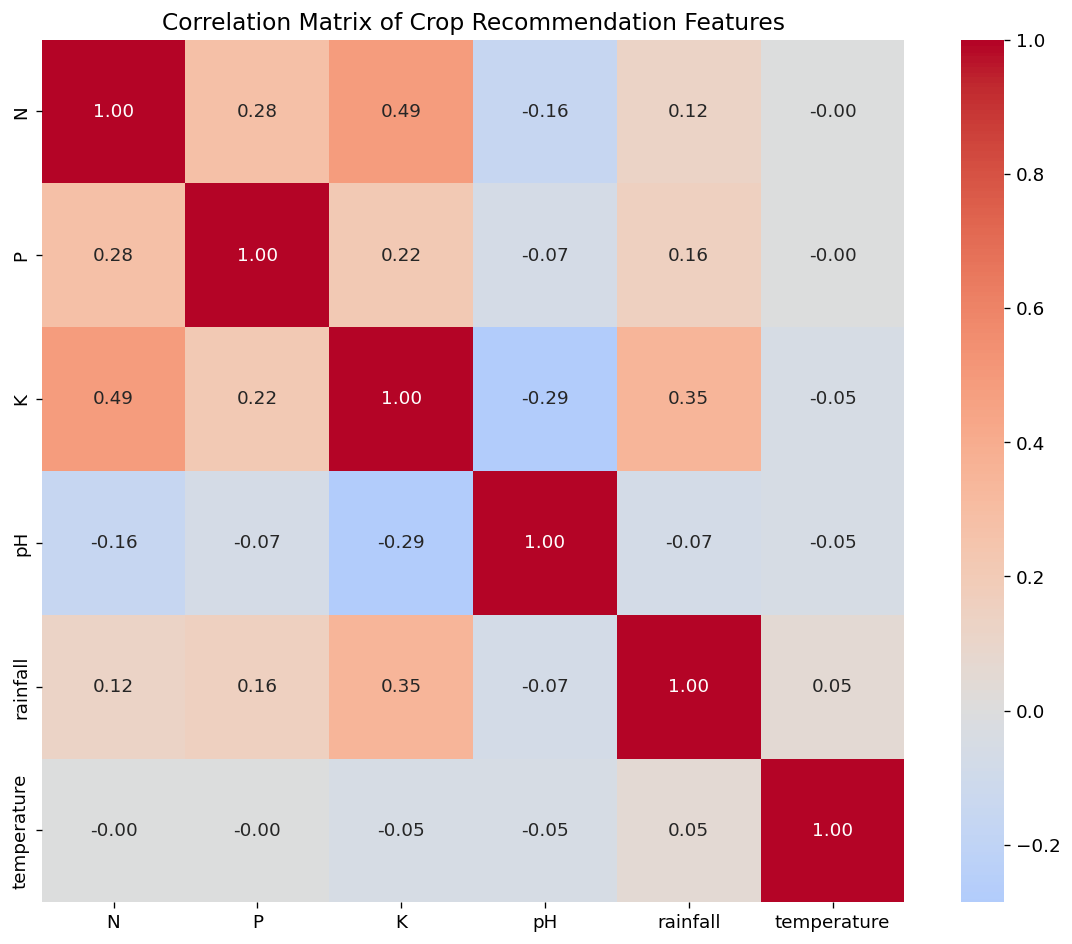

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
correlation_matrix = crop_df[FEATURES].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix of Crop Recommendation Features",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "feature_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

correlation_pairs["Absolute_Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(correlation_pairs)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
1,N,K,0.4900,0.4900
10,K,rainfall,0.3520,0.3520
9,K,pH,-0.2859,0.2859
0,N,P,0.2773,0.2773
5,P,K,0.2168,0.2168
2,N,pH,-0.1558,0.1558
7,P,rainfall,0.1551,0.1551
3,N,rainfall,0.1241,0.1241
12,pH,rainfall,-0.0708,0.0708
6,P,pH,-0.0658,0.0658


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
crop_feature_profile = (
    crop_df
    .groupby(TARGET)[FEATURES]
    .mean()
    .round(2)
)

display(crop_feature_profile)

crop_feature_profile.to_csv(
    os.path.join(
        RESULT_DIR,
        "crop_feature_profiles.csv"
    )
)

,N,P,K,pH,rainfall,temperature
Crop,,,,,,
banana,100.0000,75.0000,50.0000,6.5000,1267.4900,26.7100
barley,70.0000,40.0000,45.0000,5.5000,108.7100,21.5100
bittergourd,60.0000,10.0000,20.0000,6.5000,1538.7400,27.2800
blackgram,40.0000,60.0000,20.0000,4.9900,516.4700,27.7700
blackpepper,100.0000,60.0000,50.0000,5.0000,1953.5600,25.3300
bottlegourd,100.0000,50.0000,50.0000,6.4900,1028.3500,27.8800
brinjal,80.0000,15.0000,40.0000,6.5200,1326.2600,27.5700
cabbage,100.0000,65.0000,70.0000,6.5000,1084.9000,28.2000
cardamom,75.0000,75.0000,150.0000,5.0200,1737.4600,26.4300


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


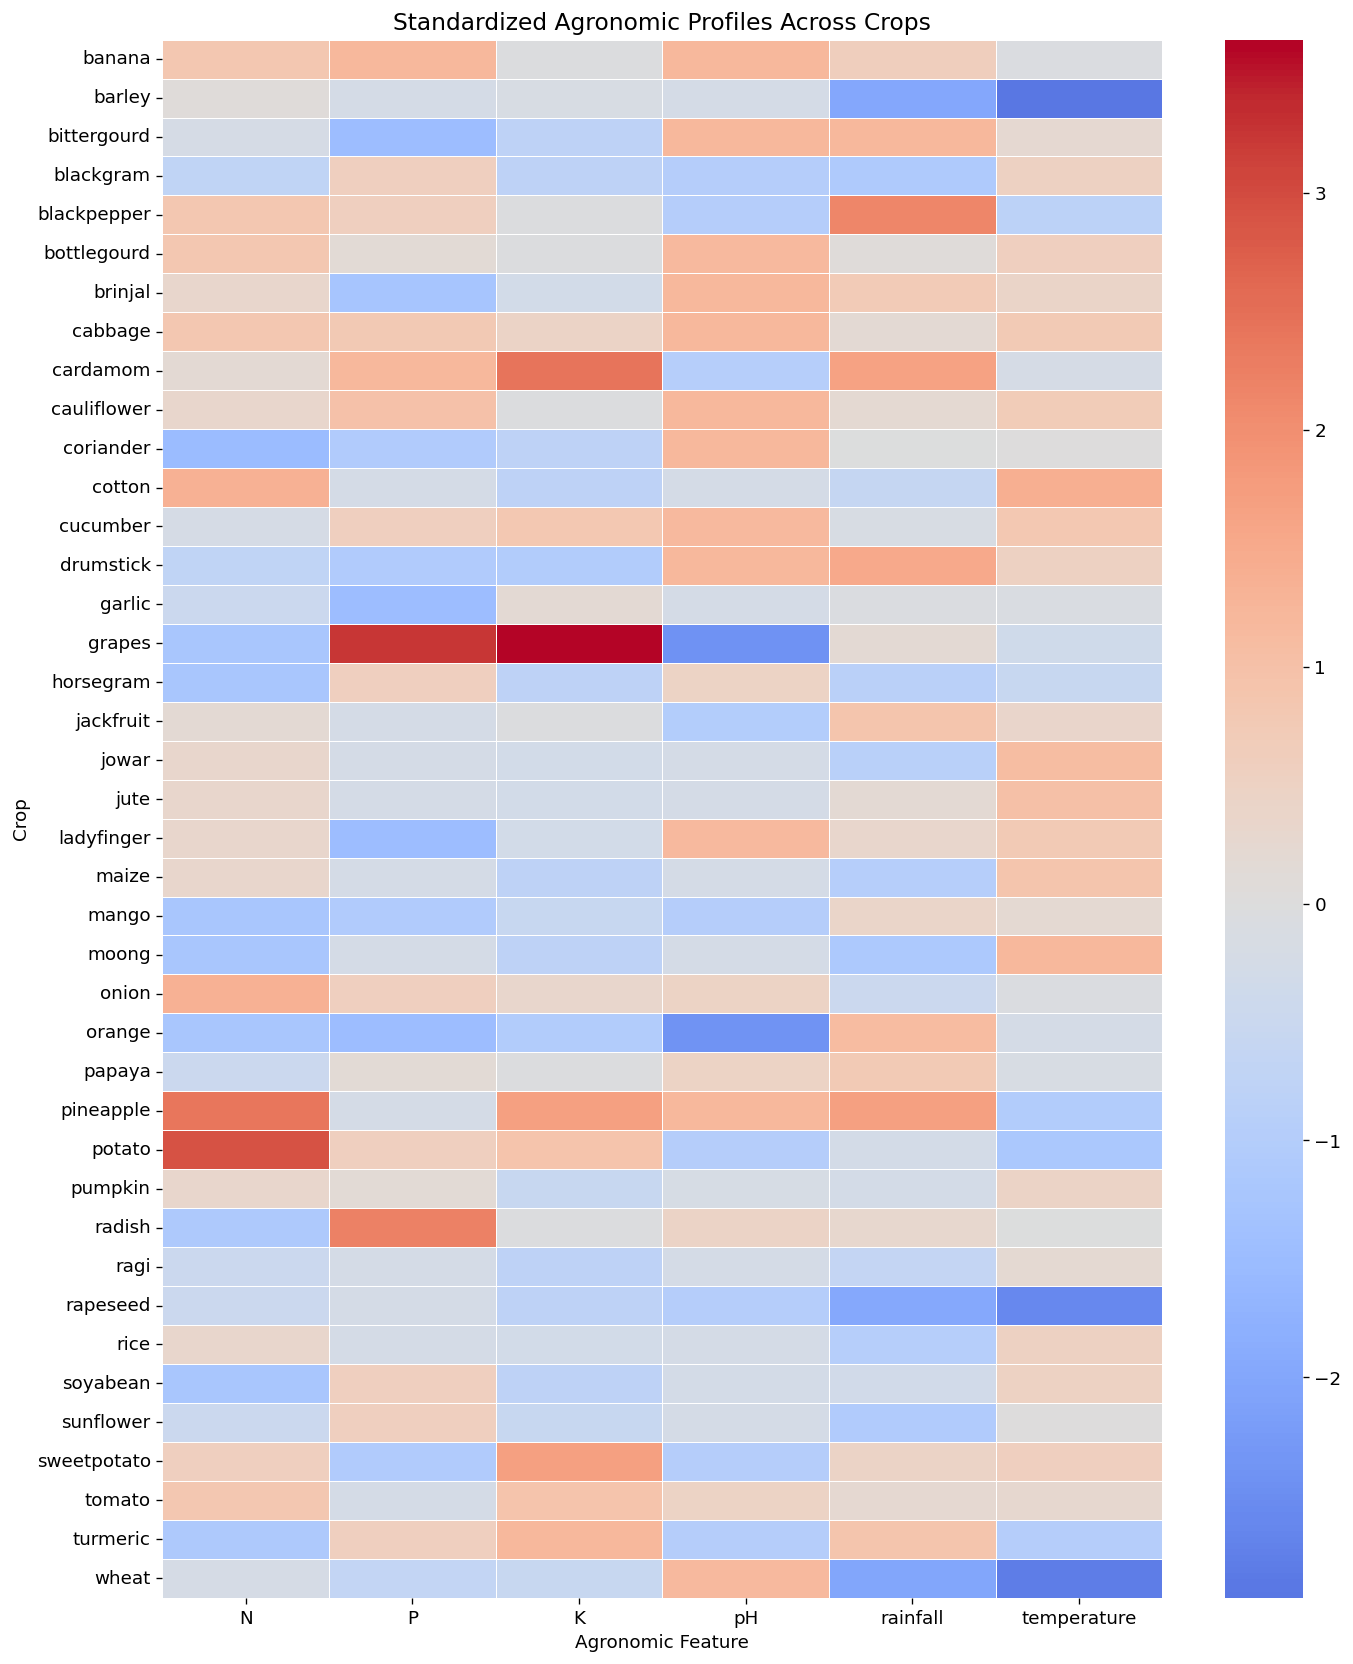

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
profile_mean = crop_feature_profile.mean()
profile_std = crop_feature_profile.std()

standardized_profile = (
    crop_feature_profile - profile_mean
) / profile_std

plt.figure(figsize=(12, 14))

sns.heatmap(
    standardized_profile,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title(
    "Standardized Agronomic Profiles Across Crops",
    fontsize=14
)

plt.xlabel("Agronomic Feature")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "crop_feature_profile_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
crop_mean_variability = (
    crop_feature_profile
    .std()
    .sort_values(ascending=False)
)

display(
    crop_mean_variability.to_frame(
        name="Std_of_Crop_Means"
    )
)

,Std_of_Crop_Means
rainfall,445.9372
K,40.5394
N,38.4107
P,24.3502
temperature,1.8110
pH,0.6955


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
skewness_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "feature_skewness.csv"
    ),
    index=False
)

outlier_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "feature_outlier_summary.csv"
    ),
    index=False
)

correlation_pairs.to_csv(
    os.path.join(
        RESULT_DIR,
        "feature_correlations.csv"
    ),
    index=False
)

## Data Normalization

In [34]:
PRICE_DATA_PATH = "/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/price_dataset.csv"

price_df = pd.read_csv(PRICE_DATA_PATH)

print("Price dataset shape:", price_df.shape)
display(price_df.head())

Price dataset shape: (62429, 11)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,APMC,Commodity,Year,Month,arrivals_in_qtl,min_price,max_price,modal_price,date,district_name,state_name
0,Ahmednagar,Bajri,2015,April,79,1406,1538,1463,2015-04,Ahmadnagar,Maharashtra
1,Ahmednagar,Bajri,2016,April,106,1788,1925,1875,2016-04,Ahmadnagar,Maharashtra
2,Ahmednagar,Wheat(Husked),2015,April,1253,1572,1890,1731,2015-04,Ahmadnagar,Maharashtra
3,Ahmednagar,Wheat(Husked),2016,April,387,1750,2220,1999,2016-04,Ahmadnagar,Maharashtra
4,Ahmednagar,Sorgum(Jawar),2015,April,3825,1600,2200,1900,2015-04,Ahmadnagar,Maharashtra


In [35]:
price_df["Commodity"] = (
    price_df["Commodity"]
    .astype(str)
    .str.strip()
    .str.lower()
)

crop_df["Crop"] = (
    crop_df["Crop"]
    .astype(str)
    .str.strip()
    .str.lower()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
commodity_mapping = {
    "sorgum(jawar)": "jowar",
    "wheat(husked)": "wheat",
    "wheat(unhusked)": "wheat",
    "bajri": "bajra",
    "papai": "papaya",
    "rice(paddy-hus)": "rice"
}

In [37]:
price_df["Commodity"] = (
    price_df["Commodity"]
    .replace(commodity_mapping)
)

In [38]:
crop_classes = set(
    crop_df["Crop"].unique()
)

price_classes = set(
    price_df["Commodity"].unique()
)

common_crops = sorted(
    crop_classes.intersection(price_classes)
)

print("Crop Dataset Classes :", len(crop_classes))
print("Price Dataset Classes:", len(price_classes))
print("Common Crops         :", len(common_crops))

print("\nSupported Crops:")
print(common_crops)

Crop Dataset Classes : 40
Price Dataset Classes: 201
Common Crops         : 24

Supported Crops:
['banana', 'brinjal', 'cabbage', 'cardamom', 'coriander', 'cotton', 'cucumber', 'garlic', 'grapes', 'jowar', 'maize', 'mango', 'onion', 'orange', 'papaya', 'pineapple', 'potato', 'pumpkin', 'radish', 'rice', 'sunflower', 'tomato', 'turmeric', 'wheat']


In [39]:
crop_df = crop_df[
    crop_df["Crop"].isin(common_crops)
].copy()

crop_df.reset_index(
    drop=True,
    inplace=True
)

print("Final dataset shape:", crop_df.shape)
print(
    "Final crop classes:",
    crop_df["Crop"].nunique()
)

Final dataset shape: (12396, 7)
Final crop classes: 24


## **Section 4 — Data Preprocessing & Final Dataset Preparation**

Purpose:
This section prepares the crop recommendation dataset for machine learning after completing the data-quality audit and exploratory analysis. The objective is to separate predictors and target labels, encode the categorical crop target, and establish a reproducible dataset representation for subsequent model training.

Preprocessing decisions are kept minimal because unnecessary transformations can alter meaningful agricultural patterns. In particular, numerical features are not permanently standardized at this stage because tree-based models such as Random Forest and XGBoost do not require feature scaling. Scaling will later be incorporated only for algorithms that require it.

The target crop labels are encoded numerically while preserving the mapping between encoded classes and original crop names. This mapping is essential for generating interpretable Top-3 crop recommendations during inference.

In [40]:
X = crop_df[FEATURES].copy()
y = crop_df[TARGET].copy()

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [41]:
class_mapping = pd.DataFrame({
    "Encoded_Label": range(
        len(label_encoder.classes_)
    ),
    "Crop": label_encoder.classes_
})

display(class_mapping)

class_mapping.to_csv(
    os.path.join(
        RESULT_DIR,
        "crop_class_mapping.csv"
    ),
    index=False
)

,Encoded_Label,Crop
0,0,banana
1,1,brinjal
2,2,cabbage
3,3,cardamom
4,4,coriander
5,5,cotton
6,6,cucumber
7,7,garlic
8,8,grapes
9,9,jowar


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Only Common Crops are Selected for model training

In [42]:
print("Dataset shape :", crop_df.shape)
print("Crop classes  :", crop_df[TARGET].nunique())

print("\nFinal Crops:")
print(sorted(crop_df[TARGET].unique()))

Dataset shape : (12396, 7)
Crop classes  : 24

Final Crops:
['banana', 'brinjal', 'cabbage', 'cardamom', 'coriander', 'cotton', 'cucumber', 'garlic', 'grapes', 'jowar', 'maize', 'mango', 'onion', 'orange', 'papaya', 'pineapple', 'potato', 'pumpkin', 'radish', 'rice', 'sunflower', 'tomato', 'turmeric', 'wheat']


In [43]:
final_class_counts = (
    crop_df[TARGET]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    final_class_counts.to_frame(
        name="Sample_Count"
    )
)

print(
    "\nLargest class:",
    final_class_counts.max()
)

print(
    "Smallest class:",
    final_class_counts.min()
)

print(
    "Imbalance ratio:",
    round(
        final_class_counts.max()
        / final_class_counts.min(),
        2
    )
)

,Sample_Count
Crop,
rice,2245
maize,1976
wheat,1287
potato,1083
jowar,1055
onion,1047
sunflower,737
cotton,613
turmeric,528



Largest class: 2245
Smallest class: 9
Imbalance ratio: 249.44


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [44]:
X = crop_df[FEATURES].copy()
y = crop_df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12396, 6)
y shape: (12396,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [45]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(
    "Number of encoded classes:",
    len(label_encoder.classes_)
)

Number of encoded classes: 24


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [46]:
class_mapping = pd.DataFrame({
    "Encoded_Label":
        range(len(label_encoder.classes_)),

    "Crop":
        label_encoder.classes_
})

display(class_mapping)

,Encoded_Label,Crop
0,0,banana
1,1,brinjal
2,2,cabbage
3,3,cardamom
4,4,coriander
5,5,cotton
6,6,cucumber
7,7,garlic
8,8,grapes
9,9,jowar


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
verification_df = pd.DataFrame({
    "Original":
        y.iloc[:10].values,

    "Encoded":
        y_encoded[:10],

    "Decoded":
        label_encoder.inverse_transform(
            y_encoded[:10]
        )
})

display(verification_df)

class_mapping.to_csv(
    os.path.join(
        RESULT_DIR,
        "crop_class_mapping.csv"
    ),
    index=False
)

,Original,Encoded,Decoded
0,sunflower,20,sunflower
1,rice,19,rice
2,jowar,9,jowar
3,potato,16,potato
4,rice,19,rice
5,turmeric,22,turmeric
6,rice,19,rice
7,turmeric,22,turmeric
8,potato,16,potato
9,maize,10,maize


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **Section 5 — Experimental Data Splitting & Validation Strategy**

Purpose:
This section establishes the experimental validation strategy used to train and evaluate the crop recommendation models. The dataset is divided into independent training and testing subsets using a stratified split, ensuring that the relative distribution of all 24 crop classes is approximately preserved in both subsets.

The training dataset will be used for model development, cross-validation, and hyperparameter optimization, while the test dataset will remain completely unseen until final model evaluation.

Additionally, Stratified K-Fold Cross-Validation is used on the training dataset to provide a more reliable estimate of model generalization than a single train-validation split. This is particularly important for the present multiclass classification problem because the crop classes contain different numbers of observations.

This strategy also prevents information from the test set from influencing model selection or hyperparameter tuning, reducing the risk of overly optimistic performance estimates.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("\nTraining features shape:", X_train.shape)
print("Testing features shape :", X_test.shape)

Training samples : 9916
Testing samples  : 2480

Training features shape: (9916, 6)
Testing features shape : (2480, 6)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
print(
    "Classes in training set:",
    len(np.unique(y_train))
)

print(
    "Classes in testing set:",
    len(np.unique(y_test))
)

Classes in training set: 24
Classes in testing set: 24


In [50]:
train_counts = pd.Series(
    y_train
).value_counts().sort_index()

test_counts = pd.Series(
    y_test
).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "Encoded_Label": range(
        len(label_encoder.classes_)
    ),
    "Crop": label_encoder.classes_,
    "Train_Count": train_counts,
    "Test_Count": test_counts
}).reset_index(drop=True)

split_distribution["Train_Percentage"] = (
    split_distribution["Train_Count"]
    / len(y_train)
    * 100
)

split_distribution["Test_Percentage"] = (
    split_distribution["Test_Count"]
    / len(y_test)
    * 100
)

display(split_distribution)

split_distribution.to_csv(
    os.path.join(
        RESULT_DIR,
        "train_test_class_distribution.csv"
    ),
    index=False
)

,Encoded_Label,Crop,Train_Count,Test_Count,Train_Percentage,Test_Percentage
0,0,banana,406,101,4.0944,4.0726
1,1,brinjal,44,11,0.4437,0.4435
2,2,cabbage,21,5,0.2118,0.2016
3,3,cardamom,43,11,0.4336,0.4435
4,4,coriander,378,95,3.8120,3.8306
5,5,cotton,490,123,4.9415,4.9597
6,6,cucumber,16,4,0.1614,0.1613
7,7,garlic,332,83,3.3481,3.3468
8,8,grapes,15,4,0.1513,0.1613
9,9,jowar,844,211,8.5115,8.5081


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [51]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **Section 6 — Baseline Model Development**

Purpose:
This section establishes baseline performance for multiple machine learning classifiers on the crop recommendation problem. Different algorithm families are evaluated under the same 5-fold Stratified Cross-Validation strategy to ensure a fair comparison.

Scale-sensitive algorithms such as Logistic Regression, KNN, and SVM are combined with StandardScaler using preprocessing pipelines, while tree-based algorithms operate directly on the original feature values.

Model performance is evaluated using Accuracy, Macro Precision, Macro Recall, Macro F1-score, and Weighted F1-score. Macro F1 is particularly important because it gives equal importance to every crop class regardless of class frequency. Undefined class-level metrics are assigned a value of zero when a model fails to predict a particular crop.

The results of this experiment will be used to identify the strongest candidate algorithms for subsequent hyperparameter optimization.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

In [53]:
scoring = {
    "accuracy": "accuracy",

    "precision_macro": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),

    "recall_macro": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),

    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    ),

    "f1_weighted": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0
    )
}

In [54]:
baseline_models = {

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "KNN": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            KNeighborsClassifier()
        )
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_jobs=-1
    ),

    "SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                random_state=RANDOM_STATE
            )
        )
    ])
}

In [55]:
baseline_results = []

for model_name, model in baseline_models.items():

    print(f"Evaluating: {model_name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({

        "Model": model_name,

        "Accuracy_Mean":
            scores["test_accuracy"].mean(),

        "Accuracy_Std":
            scores["test_accuracy"].std(),

        "Precision_Macro":
            scores["test_precision_macro"].mean(),

        "Recall_Macro":
            scores["test_recall_macro"].mean(),

        "F1_Macro":
            scores["test_f1_macro"].mean(),

        "F1_Macro_Std":
            scores["test_f1_macro"].std(),

        "F1_Weighted":
            scores["test_f1_weighted"].mean()
    })

print("\nBaseline model evaluation completed.")

Evaluating: Logistic Regression


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluating: KNN
Evaluating: Decision Tree


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluating: Random Forest


...

Evaluating: XGBoost


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluating: SVM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Baseline model evaluation completed.


In [56]:
baseline_results_df = pd.DataFrame(
    baseline_results
)

baseline_results_df = (
    baseline_results_df
    .sort_values(
        by="F1_Macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    baseline_results_df.round(4)
)

,Model,Accuracy_Mean,Accuracy_Std,Precision_Macro,Recall_Macro,F1_Macro,F1_Macro_Std,F1_Weighted
0,Extra Trees,0.9208,0.0029,0.9721,0.9728,0.9723,0.0007,0.9218
1,Decision Tree,0.9199,0.0032,0.9718,0.9726,0.9721,0.0006,0.9211
2,XGBoost,0.9251,0.0026,0.9728,0.9710,0.9718,0.0014,0.9240
3,Random Forest,0.9224,0.0011,0.9719,0.9715,0.9717,0.0006,0.9218
4,KNN,0.9236,0.0031,0.9701,0.9715,0.9707,0.0015,0.9228
5,SVM,0.9145,0.0006,0.9283,0.9417,0.9337,0.0204,0.8800
6,Logistic Regression,0.9134,0.0005,0.9020,0.9025,0.8981,0.0087,0.8784


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [57]:
display_df = baseline_results_df.copy()

percentage_columns = [
    "Accuracy_Mean",
    "Accuracy_Std",
    "Precision_Macro",
    "Recall_Macro",
    "F1_Macro",
    "F1_Macro_Std",
    "F1_Weighted"
]

display_df[percentage_columns] = (
    display_df[percentage_columns] * 100
)

display(
    display_df.round(2)
)

,Model,Accuracy_Mean,Accuracy_Std,Precision_Macro,Recall_Macro,F1_Macro,F1_Macro_Std,F1_Weighted
0,Extra Trees,92.0800,0.2900,97.2100,97.2800,97.2300,0.0700,92.1800
1,Decision Tree,91.9900,0.3200,97.1800,97.2600,97.2100,0.0600,92.1100
2,XGBoost,92.5100,0.2600,97.2800,97.1000,97.1800,0.1400,92.4000
3,Random Forest,92.2400,0.1100,97.1900,97.1500,97.1700,0.0600,92.1800
4,KNN,92.3600,0.3100,97.0100,97.1500,97.0700,0.1500,92.2800
5,SVM,91.4500,0.0600,92.8300,94.1700,93.3700,2.0400,88.0000
6,Logistic Regression,91.3400,0.0500,90.2000,90.2500,89.8100,0.8700,87.8400


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


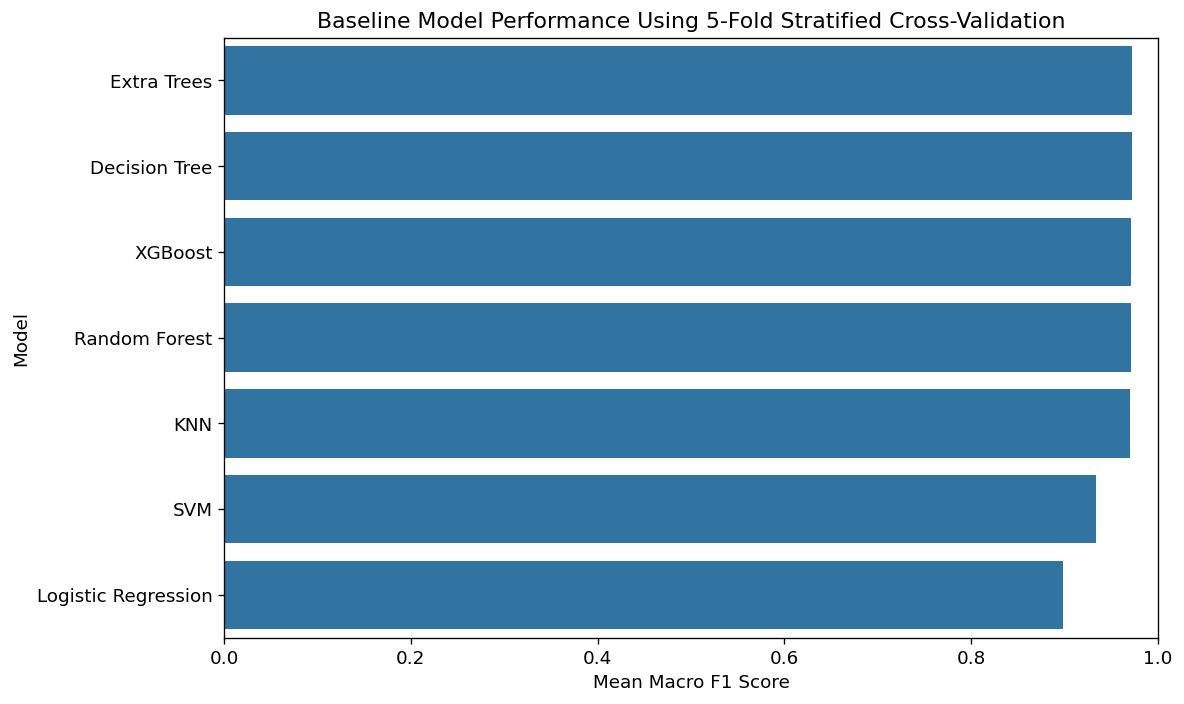

Baseline results saved successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_df,
    x="F1_Macro",
    y="Model"
)

plt.title(
    "Baseline Model Performance Using 5-Fold Stratified Cross-Validation"
)

plt.xlabel("Mean Macro F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "baseline_model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

baseline_results_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "baseline_model_comparison.csv"
    ),
    index=False
)

print("Baseline results saved successfully.")

In [59]:
best_baseline = baseline_results_df.iloc[0]

print("=" * 60)
print("BEST BASELINE MODEL")
print("=" * 60)

print(
    f"Model          : {best_baseline['Model']}"
)

print(
    f"Accuracy       : "
    f"{best_baseline['Accuracy_Mean']:.4f}"
)

print(
    f"Macro F1       : "
    f"{best_baseline['F1_Macro']:.4f}"
)

print(
    f"Macro F1 Std   : "
    f"{best_baseline['F1_Macro_Std']:.4f}"
)

print(
    f"Weighted F1    : "
    f"{best_baseline['F1_Weighted']:.4f}"
)

BEST BASELINE MODEL
Model          : Extra Trees
Accuracy       : 0.9208
Macro F1       : 0.9723
Macro F1 Std   : 0.0007
Weighted F1    : 0.9218


In [60]:
from sklearn.model_selection import cross_val_predict

oof_predictions = cross_val_predict(
    baseline_models["Extra Trees"],
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [61]:
oof_report = classification_report(
    y_train,
    oof_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

oof_report_df = (
    pd.DataFrame(oof_report)
    .transpose()
)

display(
    oof_report_df.round(4)
)

,precision,recall,f1-score,support
banana,1.0000,1.0000,1.0000,406.0000
brinjal,1.0000,1.0000,1.0000,44.0000
cabbage,1.0000,1.0000,1.0000,21.0000
cardamom,1.0000,1.0000,1.0000,43.0000
coriander,1.0000,1.0000,1.0000,378.0000
cotton,1.0000,1.0000,1.0000,490.0000
cucumber,1.0000,1.0000,1.0000,16.0000
garlic,1.0000,1.0000,1.0000,332.0000
grapes,1.0000,1.0000,1.0000,15.0000
jowar,0.5314,0.5912,0.5597,844.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [62]:
class_performance = (
    oof_report_df
    .iloc[:len(label_encoder.classes_)]
    .sort_values(
        "support",
        ascending=False
    )
)

display(
    class_performance.round(4)
)

,precision,recall,f1-score,support
rice,0.7972,0.7550,0.7755,1796.0000
maize,1.0000,1.0000,1.0000,1581.0000
wheat,1.0000,1.0000,1.0000,1029.0000
potato,1.0000,1.0000,1.0000,866.0000
jowar,0.5314,0.5912,0.5597,844.0000
onion,1.0000,1.0000,1.0000,838.0000
sunflower,1.0000,1.0000,1.0000,590.0000
cotton,1.0000,1.0000,1.0000,490.0000
turmeric,1.0000,1.0000,1.0000,422.0000
banana,1.0000,1.0000,1.0000,406.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [63]:
worst_classes = (
    class_performance
    .sort_values("f1-score")
    .head(5)
)

display(
    worst_classes[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)

,precision,recall,f1-score,support
jowar,0.5314,0.5912,0.5597,844.0000
rice,0.7972,0.7550,0.7755,1796.0000
wheat,1.0000,1.0000,1.0000,1029.0000
maize,1.0000,1.0000,1.0000,1581.0000
potato,1.0000,1.0000,1.0000,866.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [68]:
best_classes = (
    class_performance
    .sort_values(
        "f1-score",
        ascending=False
    )
    .head(10)
)

display(
    best_classes[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)

class_performance.to_csv(
    os.path.join(
        RESULT_DIR,
        "extra_trees_class_performance.csv"
    )
)

,precision,recall,f1-score,support
banana,1.0000,1.0000,1.0000,406.0000
cabbage,1.0000,1.0000,1.0000,21.0000
cotton,1.0000,1.0000,1.0000,490.0000
coriander,1.0000,1.0000,1.0000,378.0000
cucumber,1.0000,1.0000,1.0000,16.0000
brinjal,1.0000,1.0000,1.0000,44.0000
grapes,1.0000,1.0000,1.0000,15.0000
garlic,1.0000,1.0000,1.0000,332.0000
pineapple,1.0000,1.0000,1.0000,21.0000
potato,1.0000,1.0000,1.0000,866.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Why are we selecting Random Forest, Extra Trees, and XGBoost?**

Before hyperparameter tuning, we evaluated seven different classification algorithms using the same 5-fold Stratified Cross-Validation setup:

Logistic Regression
K-Nearest Neighbors
Decision Tree
Random Forest
Extra Trees
XGBoost
Support Vector Machine

The purpose was to compare different types of machine-learning algorithms fairly before deciding which models deserved further optimization.

Our baseline results showed:

Model	Accuracy	Macro F1	Weighted F1
Extra Trees	92.08%	97.23%	92.18%
Decision Tree	91.99%	97.21%	92.11%
XGBoost	92.51%	97.18%	92.40%
Random Forest	92.24%	97.17%	92.18%
KNN	92.36%	97.07%	92.28%
SVM	91.45%	93.37%	88.00%
Logistic Regression	91.34%	89.81%	87.84%
Why XGBoost?

XGBoost achieved the highest cross-validation accuracy (92.51%) and highest Weighted F1 (92.40%) among all baseline models.

It uses gradient boosting, where trees are built sequentially and each new tree attempts to correct errors made by previous trees.

Therefore, XGBoost was selected because it showed the strongest overall baseline classification performance.

Why Extra Trees?

Extra Trees achieved the highest Macro F1 score (97.23%).

Unlike Random Forest, Extra Trees introduces additional randomness when selecting split points. Combining many highly randomized decision trees can reduce variance and produce strong generalization.

It was therefore selected because it demonstrated excellent class-level performance and very stable cross-validation results.

Why Random Forest?

Random Forest achieved:

Accuracy: 92.24%
Macro F1: 97.17%
Macro F1 standard deviation: only 0.06%

So it was both strong and highly stable across the five folds.

Random Forest is also particularly useful for our research because it provides a strong tree-ensemble model that can later be analyzed using feature importance and SHAP explainability.


**We first trained seven baseline models rather than directly choosing Random Forest or XGBoost. After evaluating all models using the same 5-fold stratified cross-validation, XGBoost had the highest accuracy and Weighted F1, Extra Trees had the highest Macro F1, and Random Forest demonstrated strong and highly stable performance. Therefore, these three ensemble models were selected for GridSearchCV hyperparameter optimization. The final model will only be chosen after comparing their optimized performance.**

In [69]:
def show_crop_confusions(crop_name, top_n=5):

    crop_label = label_encoder.transform(
        [crop_name]
    )[0]

    mask = y_train == crop_label

    actual_predictions = oof_predictions[mask]

    predicted_counts = pd.Series(
        label_encoder.inverse_transform(
            actual_predictions
        )
    ).value_counts()

    result = (
        predicted_counts
        .head(top_n)
        .rename_axis("Predicted_Crop")
        .reset_index(name="Count")
    )

    result["Percentage"] = (
        result["Count"] /
        mask.sum() * 100
    )

    return result

In [74]:
display(
    show_crop_confusions("jowar")
)

,Predicted_Crop,Count,Percentage
0,jowar,499,59.1232
1,rice,345,40.8768


In [75]:
display(
    show_crop_confusions("rice")
)

,Predicted_Crop,Count,Percentage
0,rice,1356,75.5011
1,jowar,440,24.4989


## **Section 7 — Hyperparameter Tuning using GridSearchCV**

Purpose:
Following baseline model evaluation, Random Forest, Extra Trees, and XGBoost were selected as the strongest candidate algorithms. However, baseline models primarily use default hyperparameter configurations, which may not provide optimal performance for the current crop recommendation dataset.

Therefore, GridSearchCV is used to systematically evaluate multiple combinations of important hyperparameters. Each parameter combination is evaluated using the previously defined 5-fold Stratified Cross-Validation, and Macro F1-score is used as the optimization metric.

Hyperparameter tuning is performed exclusively on the training dataset. The independent test dataset remains untouched to prevent data leakage and preserve an unbiased final evaluation.

### RANDOM FOREST

In [76]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [77]:
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [78]:
print("=" * 60)
print("RANDOM FOREST TUNING RESULTS")
print("=" * 60)

print(
    f"Best CV Macro F1: "
    f"{rf_grid.best_score_:.4f}"
)

print("\nBest Parameters:")

for parameter, value in rf_grid.best_params_.items():
    print(f"{parameter}: {value}")

RANDOM FOREST TUNING RESULTS
Best CV Macro F1: 0.9719

Best Parameters:
max_depth: 20
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 10
n_estimators: 300


In [115]:
joblib.dump(
    best_rf,
    os.path.join(
        MODEL_DIR,
        "crop_random_forest_model.pkl"
    )
)

['/kaggle/working/crop_recommendation/models/crop_random_forest_model.pkl']

In [79]:
best_rf = rf_grid.best_estimator_

### EXTRA TREES

In [80]:
et = ExtraTreesClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [81]:
et_grid = GridSearchCV(
    estimator=et,
    param_grid=et_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

et_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=ExtraTreesClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [82]:
print("=" * 60)
print("EXTRA TREES TUNING RESULTS")
print("=" * 60)

print(
    f"Best CV Macro F1: "
    f"{et_grid.best_score_:.4f}"
)

print("\nBest Parameters:")

for parameter, value in et_grid.best_params_.items():
    print(f"{parameter}: {value}")

EXTRA TREES TUNING RESULTS
Best CV Macro F1: 0.9728

Best Parameters:
max_depth: None
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 5
n_estimators: 100


In [116]:
joblib.dump(
    best_et,
    os.path.join(
        MODEL_DIR,
        "crop_extra_trees_model.pkl"
    )
)

['/kaggle/working/crop_recommendation/models/crop_extra_trees_model.pkl']

In [83]:
best_et = et_grid.best_estimator_

### XGBoost

In [85]:
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [86]:
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [87]:
print("=" * 60)
print("XGBOOST TUNING RESULTS")
print("=" * 60)

print(
    f"Best CV Macro F1: "
    f"{xgb_grid.best_score_:.4f}"
)

print("\nBest Parameters:")

for parameter, value in xgb_grid.best_params_.items():
    print(f"{parameter}: {value}")

XGBOOST TUNING RESULTS
Best CV Macro F1: 0.9730

Best Parameters:
colsample_bytree: 0.8
learning_rate: 0.1
max_depth: 6
n_estimators: 200
subsample: 1.0


In [117]:
joblib.dump(
    best_xgb,
    os.path.join(
        MODEL_DIR,
        "crop_xgboost_model.pkl"
    )
)

['/kaggle/working/crop_recommendation/models/crop_xgboost_model.pkl']

In [88]:
best_xgb = xgb_grid.best_estimator_

### Compare Baseline vs Tuned Performance

In [89]:
baseline_lookup = (
    baseline_results_df
    .set_index("Model")["F1_Macro"]
)

tuning_results_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],

    "Baseline_Macro_F1": [
        baseline_lookup["Random Forest"],
        baseline_lookup["Extra Trees"],
        baseline_lookup["XGBoost"]
    ],

    "Tuned_Macro_F1": [
        rf_grid.best_score_,
        et_grid.best_score_,
        xgb_grid.best_score_
    ]
})

In [91]:
tuning_results_df["Improvement"] = (
    tuning_results_df["Tuned_Macro_F1"]
    - tuning_results_df["Baseline_Macro_F1"]
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        "Tuned_Macro_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuning_results_df.round(4)
)

tuning_results_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "hyperparameter_tuning_comparison.csv"
    ),
    index=False
)

,Model,Baseline_Macro_F1,Tuned_Macro_F1,Improvement
0,XGBoost,0.9718,0.9730,0.0013
1,Extra Trees,0.9723,0.9728,0.0005
2,Random Forest,0.9717,0.9719,0.0003


In [92]:
pd.DataFrame(
    rf_grid.cv_results_
).to_csv(
    os.path.join(
        RESULT_DIR,
        "rf_gridsearch_results.csv"
    ),
    index=False
)

pd.DataFrame(
    et_grid.cv_results_
).to_csv(
    os.path.join(
        RESULT_DIR,
        "et_gridsearch_results.csv"
    ),
    index=False
)

pd.DataFrame(
    xgb_grid.cv_results_
).to_csv(
    os.path.join(
        RESULT_DIR,
        "xgb_gridsearch_results.csv"
    ),
    index=False
)

## **Section 8 — Final Model Evaluation**

Purpose:
After baseline comparison and hyperparameter optimization, the tuned XGBoost model achieved the highest cross-validation Macro F1-score and was selected as the final candidate model. This section evaluates the selected model on the previously unseen test dataset.

Evaluation includes conventional multiclass classification metrics such as accuracy, precision, recall, Macro F1, and Weighted F1. Since the proposed system provides farmers with three crop recommendations rather than a single prediction, Top-3 Accuracy is additionally evaluated to measure whether the correct crop appears among the model's three highest-probability recommendations.

This evaluation provides an unbiased estimate of the model's generalization performance because the test dataset was not used during model training, model selection, or hyperparameter optimization.

In [94]:
final_model = best_xgb

print("Final Candidate Model: Tuned XGBoost")
print("Best Parameters:")
print(xgb_grid.best_params_)

Final Candidate Model: Tuned XGBoost
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}


In [95]:
y_pred = final_model.predict(X_test)

In [96]:
y_proba = final_model.predict_proba(X_test)

In [97]:
print("Predictions shape :", y_pred.shape)
print("Probabilities shape:", y_proba.shape)

Predictions shape : (2480,)
Probabilities shape: (2480, 24)


In [98]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

test_f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

In [99]:
print("=" * 60)
print("FINAL TEST PERFORMANCE — XGBOOST")
print("=" * 60)

print(
    f"Accuracy        : {test_accuracy:.4f}"
)

print(
    f"Macro Precision : {test_precision_macro:.4f}"
)

print(
    f"Macro Recall    : {test_recall_macro:.4f}"
)

print(
    f"Macro F1        : {test_f1_macro:.4f}"
)

print(
    f"Weighted F1     : {test_f1_weighted:.4f}"
)

FINAL TEST PERFORMANCE — XGBOOST
Accuracy        : 0.9270
Macro Precision : 0.9734
Macro Recall    : 0.9720
Macro F1        : 0.9725
Weighted F1     : 0.9252


In [100]:
from sklearn.metrics import top_k_accuracy_score

In [101]:
top3_accuracy = top_k_accuracy_score(
    y_test,
    y_proba,
    k=3,
    labels=np.arange(
        len(label_encoder.classes_)
    )
)

print(
    f"Top-3 Accuracy : {top3_accuracy:.4f}"
)

Top-3 Accuracy : 1.0000


In [105]:
final_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Top-3 Accuracy"
    ],

    "Score": [
        test_accuracy,
        test_precision_macro,
        test_recall_macro,
        test_f1_macro,
        test_f1_weighted,
        top3_accuracy
    ]
})

display(
    final_metrics_df.round(4)
)

final_metrics_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "final_xgboost_test_metrics.csv"
    ),
    index=False
)

,Metric,Score
0,Accuracy,0.9270
1,Macro Precision,0.9734
2,Macro Recall,0.9720
3,Macro F1,0.9725
4,Weighted F1,0.9252
5,Top-3 Accuracy,1.0000


In [104]:
final_metrics_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "final_xgboost_test_metrics.csv"
    ),
    index=False
)

In [107]:
final_report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

final_report_df = (
    pd.DataFrame(final_report)
    .transpose()
)

display(
    final_report_df.round(4)
)

final_report_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "final_xgboost_classification_report.csv"
    )
)

,precision,recall,f1-score,support
banana,1.0000,1.0000,1.0000,101.0000
brinjal,1.0000,1.0000,1.0000,11.0000
cabbage,1.0000,1.0000,1.0000,5.0000
cardamom,1.0000,1.0000,1.0000,11.0000
coriander,1.0000,1.0000,1.0000,95.0000
cotton,1.0000,1.0000,1.0000,123.0000
cucumber,1.0000,1.0000,1.0000,4.0000
garlic,1.0000,1.0000,1.0000,83.0000
grapes,1.0000,1.0000,1.0000,4.0000
jowar,0.5843,0.4929,0.5347,211.0000


In [108]:
top3_indices = np.argsort(
    y_proba,
    axis=1
)[:, -3:][:, ::-1]

In [109]:
top3_crops = label_encoder.inverse_transform(
    top3_indices.ravel()
).reshape(
    top3_indices.shape
)

In [110]:
top3_probabilities = np.take_along_axis(
    y_proba,
    top3_indices,
    axis=1
)

In [111]:
sample_predictions = pd.DataFrame({

    "Actual_Crop":
        label_encoder.inverse_transform(
            y_test[:10]
        ),

    "Rank_1":
        top3_crops[:10, 0],

    "Rank_1_Probability":
        top3_probabilities[:10, 0],

    "Rank_2":
        top3_crops[:10, 1],

    "Rank_2_Probability":
        top3_probabilities[:10, 1],

    "Rank_3":
        top3_crops[:10, 2],

    "Rank_3_Probability":
        top3_probabilities[:10, 2]
})

display(
    sample_predictions.round(4)
)

,Actual_Crop,Rank_1,Rank_1_Probability,Rank_2,Rank_2_Probability,Rank_3,Rank_3_Probability
0,sunflower,sunflower,0.9994,jowar,0.0001,pumpkin,0.0001
1,rice,jowar,0.5307,rice,0.4667,maize,0.0003
2,rice,rice,0.7790,jowar,0.2189,maize,0.0003
3,cotton,cotton,0.9988,maize,0.0009,rice,0.0001
4,jowar,jowar,0.5955,rice,0.4021,maize,0.0002
5,rice,rice,0.9333,jowar,0.0650,maize,0.0002
6,sunflower,sunflower,0.9995,pumpkin,0.0001,jowar,0.0001
7,wheat,wheat,0.9996,jowar,0.0001,banana,0.0000
8,maize,maize,0.9991,rice,0.0006,cotton,0.0001
9,jowar,rice,0.5027,jowar,0.4950,maize,0.0003


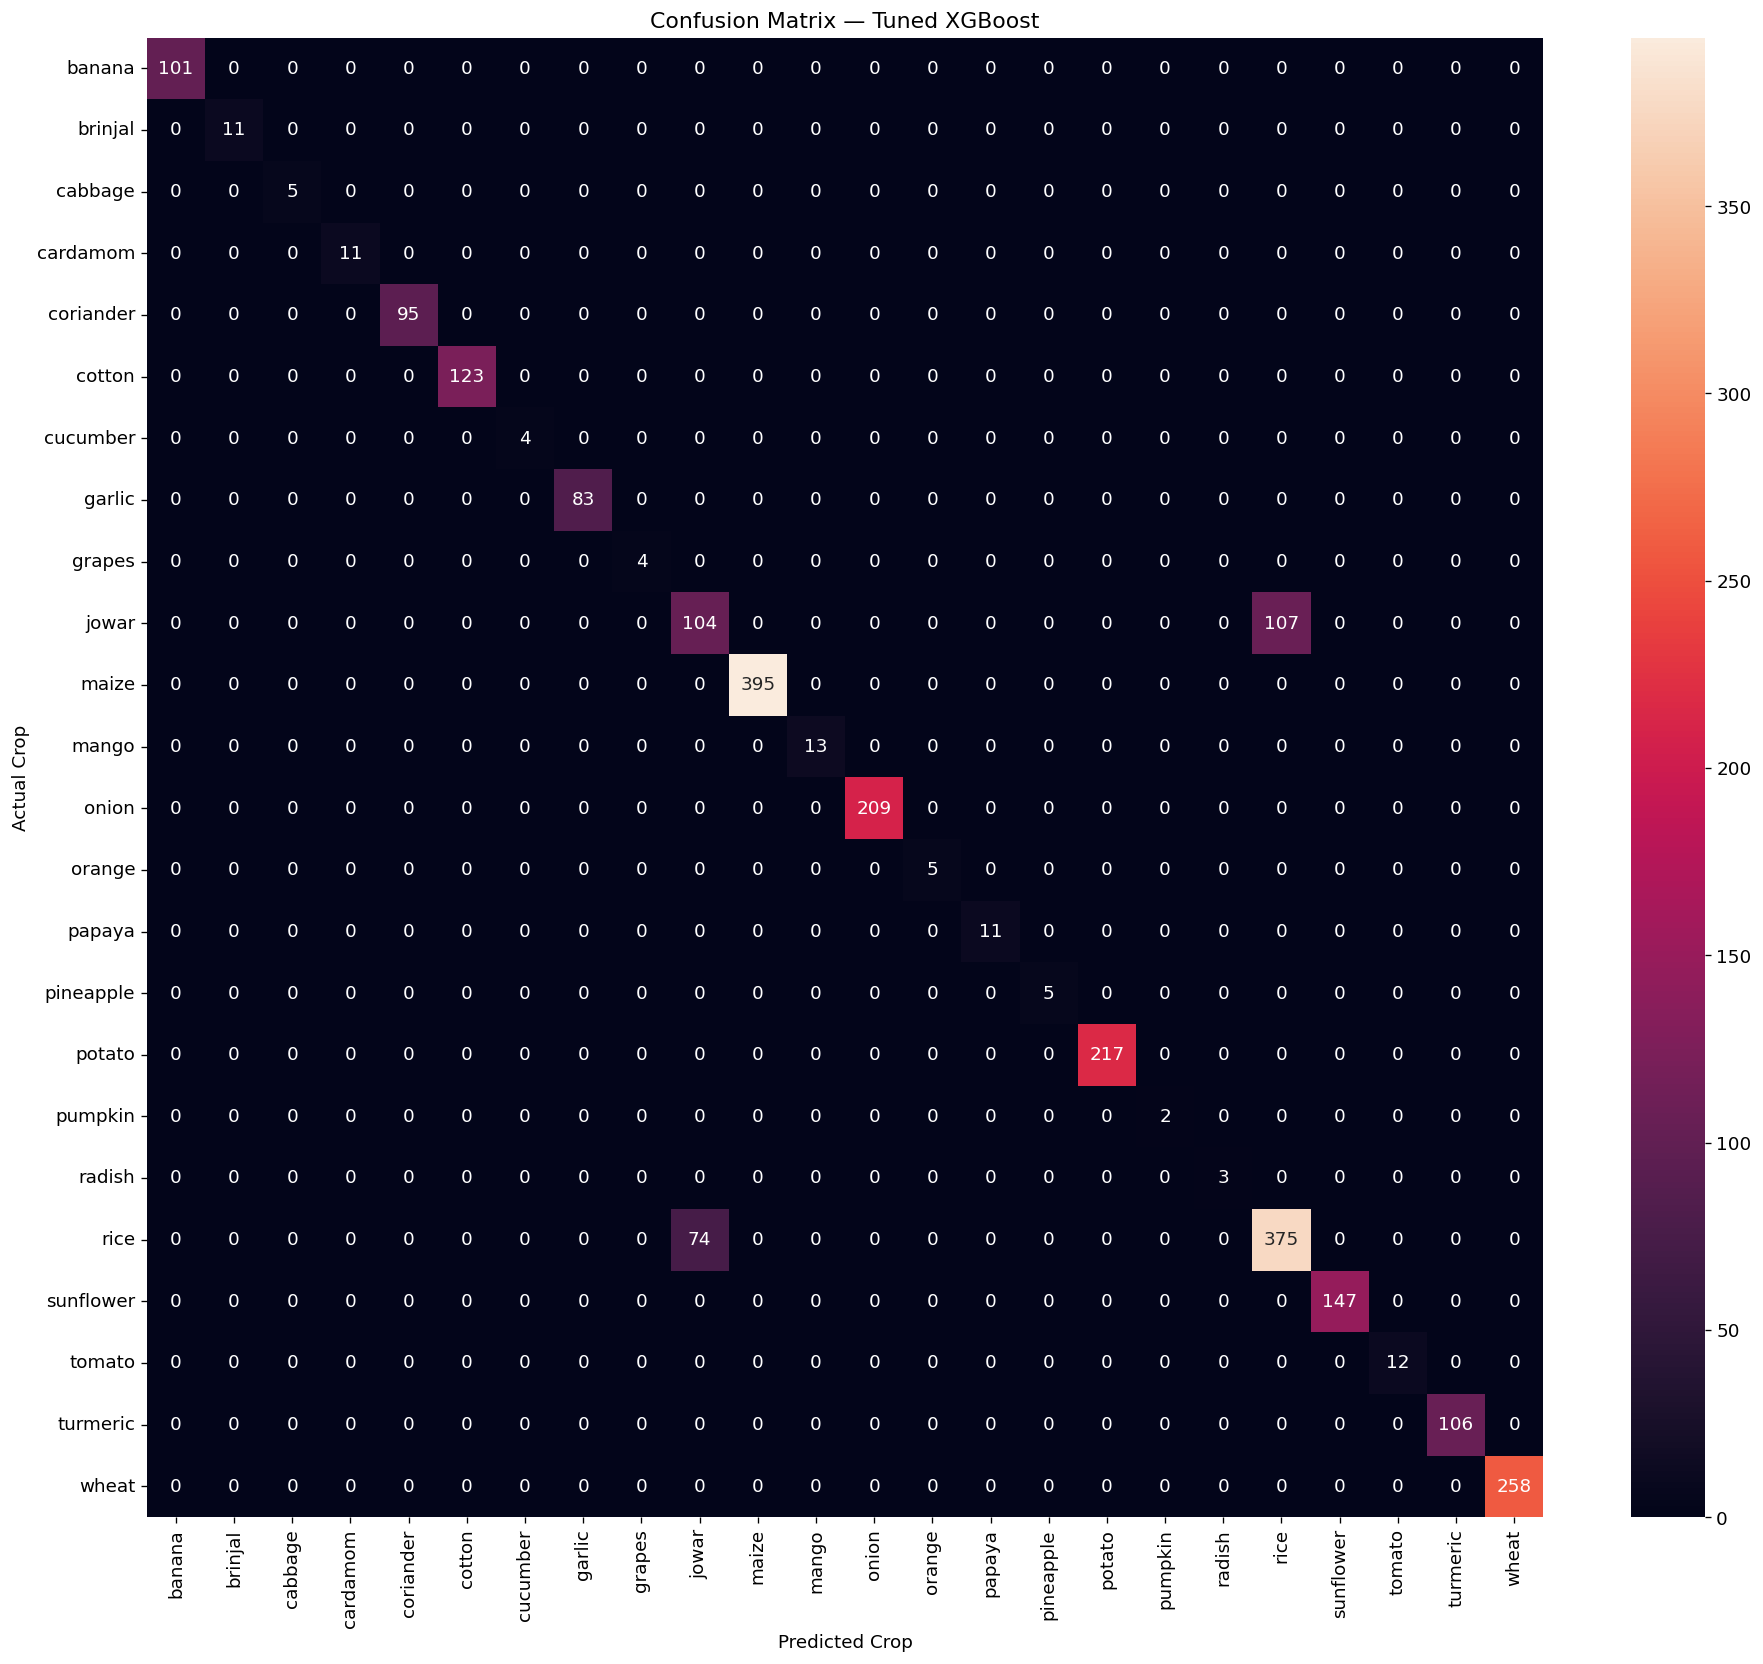

In [112]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(16, 14)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix — Tuned XGBoost"
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "xgboost_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
top_k_results = []

for k in range(1, 6):

    score = top_k_accuracy_score(
        y_test,
        y_proba,
        k=k,
        labels=np.arange(
            len(label_encoder.classes_)
        )
    )

    top_k_results.append({
        "K": k,
        "Top_K_Accuracy": score
    })

top_k_df = pd.DataFrame(top_k_results)

display(top_k_df.round(4))

,K,Top_K_Accuracy
0,1,0.9270
1,2,1.0000
2,3,1.0000
3,4,1.0000
4,5,1.0000


In [114]:
top3_indices = np.argsort(
    y_proba,
    axis=1
)[:, -3:]

top3_correct = np.array([
    true_label in predicted_labels
    for true_label, predicted_labels
    in zip(y_test, top3_indices)
])

print("Test samples :", len(y_test))
print("Top-3 correct:", top3_correct.sum())
print(
    "Top-3 errors :",
    (~top3_correct).sum()
)

Test samples : 2480
Top-3 correct: 2480
Top-3 errors : 0


In [119]:
print("Saved model files:\n")

for file in os.listdir(MODEL_DIR):
    print(file)

Saved model files:

crop_random_forest_model.pkl
crop_features.pkl
crop_extra_trees_model.pkl
crop_xgboost_model.pkl


In [121]:
import shutil

shutil.make_archive(
    "/kaggle/working/crop_recommendation",
    "zip",
    "/kaggle/working/crop_recommendation"
)

print("ZIP created successfully!")

ZIP created successfully!
